In [7]:
# Cell 1: Imports and versions
import sys, platform, re, unicodedata, html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import loguniform, reciprocal
from scipy.sparse import hstack

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python:", sys.version.split()[0], "| Platform:", platform.platform())

# NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

Python: 3.12.7 | Platform: Windows-10-10.0.19045-SP0


True

In [8]:
# Cell 2: Load data
# Expecting a CSV with columns: 'text' and 'label'
from pathlib import Path
DATA_PATH = Path("E:\\yelp_ratings.csv")  # change to your path

df = pd.read_csv(DATA_PATH)

# headers - text stars sentiment
# Rename sentiment → label
df.rename(columns={"sentiment": "label"}, inplace=True)

assert {'text', 'label'}.issubset(df.columns), "CSV must have 'text' and 'label' columns"

print("Dataset shape:", df.shape)
print(df.head(3))
print(df['label'].value_counts(normalize=True).round(3))

Dataset shape: (44530, 3)
                                                text  stars  label
0  Total bill for this horrible service? Over $8G...    1.0      0
1  I *adore* Travis at the Hard Rock's new Kelly ...    5.0      1
2  I have to say that this office really has it t...    5.0      1
label
1    0.749
0    0.251
Name: proportion, dtype: float64


In [9]:
# Cell 3: Preprocessing utilities (modernized)

URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
USER_PATTERN = re.compile(r'@\w+')
NUM_PATTERN = re.compile(r'\b\d+(\.\d+)?\b')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def normalize_unicode(text: str) -> str:
    return unicodedata.normalize('NFKC', text)

def clean_text_basic(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = normalize_unicode(text)
    text = URL_PATTERN.sub(' URL ', text)
    text = USER_PATTERN.sub(' USER ', text)
    text = NUM_PATTERN.sub(' NUM ', text)
    text = text.replace('\n', ' ').replace('\r', ' ')
    return text

def tokenize_and_lemmatize(text: str) -> str:
    # light-weight tokenization; avoid heavy stemming which can hurt NB
    tokens = nltk.word_tokenize(text)
    # keep alphanum + placeholders, drop very short tokens
    kept = []
    for t in tokens:
        t = t.lower()
        if t.isalnum() or t in {'url','user','num'}:
            if t not in stop_words:
                kept.append(lemmatizer.lemmatize(t))
    return " ".join(kept)

def preprocess_series(texts: pd.Series) -> pd.Series:
    return texts.fillna("").map(clean_text_basic).map(tokenize_and_lemmatize)

# Apply preprocessing
df['cleaned_text'] = preprocess_series(df['text'])

In [10]:
# Cell 4: Train/valid split with stratification for balanced evaluation
X = df['cleaned_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train size:", len(X_train), "Test size:", len(X_test))

Train size: 35624 Test size: 8906


In [11]:
# Cell 5: Build feature union (word + char TF-IDF)
# Character n-grams are very effective for misspellings, emojis, and style; NB loves them.

word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    norm='l2',
    strip_accents='unicode'
)

char_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    min_df=3,
    sublinear_tf=True,
    norm='l2'
)

# We’ll fit them inside a Pipeline via FeatureUnion
features = FeatureUnion([
    ('word', word_vectorizer),
    ('char', char_vectorizer)
])

In [12]:
# Cell 6: Choose a Naive Bayes variant and build a pipeline
# ComplementNB often outperforms MultinomialNB in imbalanced settings

base_nb = ComplementNB(alpha=0.5, norm=True)

pipe = Pipeline([
    ('features', features),
    ('nb', base_nb)
])

# Fit baseline
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = getattr(pipe, "predict_proba", lambda X: None)(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Baseline Accuracy: 0.7935099932629688
              precision    recall  f1-score   support

           0      0.990     0.181     0.306      2240
           1      0.784     0.999     0.879      6666

    accuracy                          0.794      8906
   macro avg      0.887     0.590     0.592      8906
weighted avg      0.836     0.794     0.735      8906



In [27]:
# cell 7 - sklearn
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_distributions = {
'features__word__ngram_range': [(1,1), (1,2)],
'features__word__min_df': [2, 3],
'features__word__max_df': [0.9, 0.95],
'features__char__ngram_range': [(3,5), (4,5)],
'features__char__min_df': [3, 5],
'nb__alpha': loguniform(1e-3, 3) # narrower range
}
from sklearn.model_selection import StratifiedKFold
cal_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
calibrated = CalibratedClassifierCV(best_model, method='sigmoid', cv=cal_cv)

search = RandomizedSearchCV(
pipe,
param_distributions=param_distributions,
n_iter=10, # fewer iterations
scoring='f1_macro', # keep macro F1 if labels imbalanced
n_jobs=-1,
cv=cv,
random_state=RANDOM_STATE,
verbose=1
)

search.fit(X_train, y_train)
print("Best CV score (f1_macro):", search.best_score_)
print("Best params:", search.best_params_)
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV score (f1_macro): 0.8957953565668887
Best params: {'features__char__min_df': 5, 'features__char__ngram_range': (3, 5), 'features__word__max_df': 0.95, 'features__word__min_df': 2, 'features__word__ngram_range': (1, 2), 'nb__alpha': 0.061384043890079884}
Tuned Accuracy: 0.9207275993712104
              precision    recall  f1-score   support

           0      0.859     0.819     0.839      2240
           1      0.940     0.955     0.947      6666

    accuracy                          0.921      8906
   macro avg      0.900     0.887     0.893      8906
weighted avg      0.920     0.921     0.920      8906



In [28]:
# Cell 8: Optional probability calibration (useful for thresholding & PR curves)
calibrated = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
calibrated.fit(X_train, y_train)

y_pred_cal = calibrated.predict(X_test)
print("Calibrated Accuracy:", accuracy_score(y_test, y_pred_cal))
print(classification_report(y_test, y_pred_cal, digits=3))

# If binary labels 0/1 -> compute ROC-AUC and PR-AUC
is_binary = len(np.unique(y_test)) == 2
if is_binary:
    y_scores = calibrated.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_scores)
    ap = average_precision_score(y_test, y_scores)
    print("ROC-AUC:", round(roc_auc, 4), "| PR-AUC:", round(ap, 4))

Calibrated Accuracy: 0.7490455872445543
              precision    recall  f1-score   support

           0      1.000     0.002     0.004      2240
           1      0.749     1.000     0.856      6666

    accuracy                          0.749      8906
   macro avg      0.874     0.501     0.430      8906
weighted avg      0.812     0.749     0.642      8906

ROC-AUC: 0.9653 | PR-AUC: 0.9868


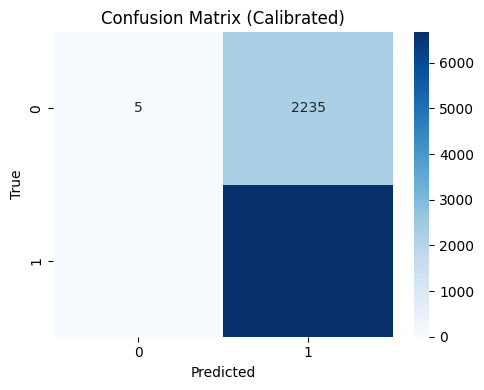

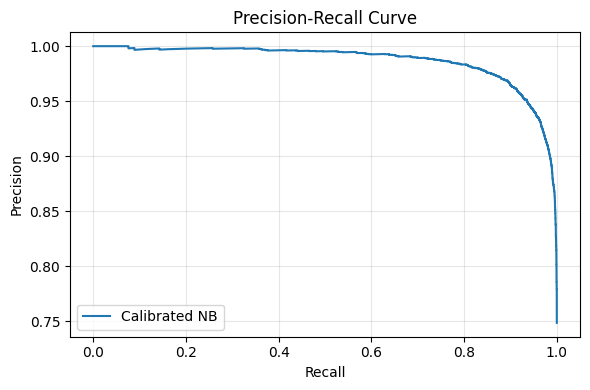

In [29]:
# Cell 9: Diagnostics – Confusion matrix and PR curve (binary)
from itertools import product
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_cal)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Calibrated)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

if is_binary:
    y_scores = calibrated.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label='Calibrated NB')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
# Cell 10: Ablation – compare NB variants quickly
def make_nb_pipeline(nb_clf):
    return Pipeline([
        ('features', features),
        ('nb', nb_clf)
    ])

variants = {
    "MultinomialNB": MultinomialNB(alpha=0.5),
    "ComplementNB": ComplementNB(alpha=0.5, norm=True),
    "BernoulliNB": BernoulliNB(alpha=0.5, binarize=0.0)
}

for name, nb in variants.items():
    pl = make_nb_pipeline(nb)
    pl.fit(X_train, y_train)
    yhat = pl.predict(X_test)
    acc = accuracy_score(y_test, yhat)
    print(f"{name:15s} | Accuracy: {acc:.4f}")

MultinomialNB   | Accuracy: 0.9107
ComplementNB    | Accuracy: 0.7935
BernoulliNB     | Accuracy: 0.8064


In [30]:
# Cell 11: Export artifacts (vectorizers + model) for deployment
import joblib
import json

ARTIFACT_DIR = Path("nb_artifacts_2025")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, ARTIFACT_DIR / "nb_best_model.joblib")
joblib.dump(calibrated, ARTIFACT_DIR / "nb_best_model_calibrated.joblib")

# Persist label mapping if necessary
labels_info = {
    "classes_": getattr(best_model, "classes_", None).tolist() if hasattr(best_model, "classes_") else None
}
(ARTIFACT_DIR / "labels.json").write_text(json.dumps(labels_info, indent=2))

print("Saved artifacts to:", ARTIFACT_DIR.resolve())

Saved artifacts to: C:\Users\DELL\nb_artifacts_2025


In [34]:
# Cell 12: Inference helper (fixed imports and hints)

from pathlib import Path
import joblib
import pandas as pd
from typing import List, Optional  # FIX: add missing typing imports
import numpy as np
# If these are not already in scope from previous cells, uncomment the following imports:
# from pathlib import Path
# import joblib
# import pandas as pd
# from typing import List, Optional
# Ensure preprocess_series and ARTIFACT_DIR are defined in previous cells.

def load_model_artifacts(path=Path("nb_artifacts_2025")):
    model = joblib.load(Path(path) / "nb_best_model_calibrated.joblib")
    return model

def predict_texts(texts: List[str], model=None, threshold: Optional[float] = None):
    if model is None:
        model = load_model_artifacts()
    cleaned = preprocess_series(pd.Series(texts))
    if threshold is None:
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(cleaned)[:, 1]
            print("Debug probs:", np.round(probs, 4))
        preds = model.predict(cleaned)
        return preds
    # thresholding for binary
    probs = model.predict_proba(cleaned)[:, 1]
    return (probs >= threshold).astype(int)

# Demo
demo_texts = [
    "i love this movie",
    "I adore Travis at the Hard Rock's new Kelly Cardenas Salon!  I'm always a fan of a great blowout and no stranger to the chains that offer this service; however, Travis has taken the flawless blowout to a whole new level!  Travis's greets you with his perfectly green swoosh in his otherwise perfectly styled black hair and a Vegas-worthy rockstar outfit.  Next comes the most relaxing and incredible shampoo -- where you get a full head message that could cure even the very worst migraine in minutes --- and the scented shampoo room.  Travis has freakishly strong fingers (in a good way) and use the perfect amount of pressure.  That was superb!  Then starts the glorious blowout... where not one, not two, but THREE people were involved in doing the best round-brush action my hair has ever seen.  The team of stylists clearly gets along extremely well, as it's evident from the way they talk to and help one another that it's really genuine and not some corporate requirement.  It was so much fun to be there! Next Travis started with the flat iron.  The way he flipped his wrist to get volume all around without over-doing it and making me look like a Texas pagent girl was admirable.  It's also worth noting that he didn't fry my hair -- something that I've had happen before with less skilled stylists.  At the end of the blowout & style my hair was perfectly bouncey and looked terrific.  The only thing better?  That this awesome blowout lasted for days! Travis, I will see you every single time I'm out in Vegas.  You make me feel beauuuutiful!"
]
print("Demo predictions:", predict_texts(demo_texts))

Debug probs: [0.7497 0.7892]
Demo predictions: [1 1]
